# PROCESO_MODELADO_CV_v2 — Stratified k=10 Cross-Validation (Colab)

> **Instructions to run:**
> 1. Run the **COLAB SETUP** cell below first
> 2. Adjust the `DRIVE_PARQUET` variable with the real path in your Google Drive
> 3. Run the cells in order with **Shift+Enter**
> 4. **Don't use Run All** — the long experiments need to run one at a time

**Total estimated time:** see the table in the notebook's introduction cell.

In [ ]:
# ── COLAB SETUP ─────────────────────────────────────────────────────────
# Step 1: mount Google Drive
from google.colab import drive
import os
# If already mounted, this line detects it automatically
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
else:
    print('Drive already mounted.')

# Step 2: install libraries not included in Colab
!pip install imbalanced-learn lime -q

# Step 3: copy the parquet file from Drive to the local Colab environment
# ─── ADJUST this path to the folder where you uploaded the parquet in your Drive ───
DRIVE_PARQUET = '/content/drive/MyDrive/fci-datos/part-00000-b5be9405-11c0-4c04-a771-bac38e228ad8-c000.snappy.parquet'
LOCAL_PARQUET = '/content/part-00000-b5be9405-11c0-4c04-a771-bac38e228ad8-c000.snappy.parquet'
# ────────────────────────────────────────────────────────────────────────────

if not os.path.exists(LOCAL_PARQUET):
    import shutil
    shutil.copy(DRIVE_PARQUET, LOCAL_PARQUET)
    print(f'Parquet copied to {LOCAL_PARQUET}')
else:
    print(f'Parquet already available at {LOCAL_PARQUET}')

print('Setup complete.')

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Parquet copiado a /content/part-00000-b5be9405-11c0-4c04-a771-bac38e228ad8-c000.snappy.parquet
Setup completado.


# MODELING PROCESS — Stratified Cross-Validation (k=10)

This notebook replaces the original notebook's `PredefinedSplit + RandomizedSearchCV` protocol
with **k=10 stratified cross-validation** and balancing **inside each fold**,
eliminating data leakage and producing metrics valid for publication in a high-impact journal.

---
### Differences from the original notebook

| Aspect | Original | This notebook |
|---|---|---|
| Balancing method | `RandomOverSampler` over the **whole** dataset | `RandomOverSampler` only over **each fold's train** |
| Evaluation | `PredefinedSplit` (1 fixed split) | `StratifiedKFold(k=10)` |
| Reported metrics | Single point value, no variance | Mean ± standard deviation per fold |
| Data leakage | Yes (balancing before split) | No |

---
### Estimated time (AMD Ryzen 7 5700G, 16 threads)
- Experiment A — RF: ~8 min | GB: ~25 min  
- Experiment B — RF: ~12 min | GB: ~40 min  
- **Total estimated: ~85 min**

## Step 1 — Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import RandomOverSampler

print('Libraries loaded successfully.')

Librerías cargadas correctamente.


In [ ]:
import os
print("Current folder:", os.getcwd())
print("\nFiles in this folder:")
for f in os.listdir():
    print(" ", f)

Carpeta actual: /content

Archivos en esta carpeta:
  .config
  part-00000-b5be9405-11c0-4c04-a771-bac38e228ad8-c000.snappy.parquet
  drive
  sample_data


## Step 2 — Load the dataset

Loads the **pre-balancing** dataset (output of PROCESO_ETL), NOT the already-balanced one.  
Balancing will be applied inside each fold to avoid data leakage.

> **Adjust the `ruta_parquet` variable** with the real path on your machine.

In [ ]:
# ─── ADJUST THIS PATH ───────────────────────────────────────────────────────
ruta_parquet = "part-00000-b5be9405-11c0-4c04-a771-bac38e228ad8-c000.snappy.parquet"
# ────────────────────────────────────────────────────────────────────────────

df_raw = pd.read_parquet(ruta_parquet)

# Normalize dtypes (the parquet uses ArrowStringArray; sklearn needs numpy)
for col in df_raw.select_dtypes(include='string').columns:
    df_raw[col] = df_raw[col].astype(object)
for col in ['NUMBER_AWARDS','LOTS_NUMBER','NUMBER_OFFERS','NUMBER_TENDERS_SME',
            'YEAR','ID_TYPE','CRIT_PRICE_WEIGHT']:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].astype(int)
df_raw['DURATION']    = df_raw['DURATION'].astype(float)
df_raw['VALUE_EURO']  = pd.to_numeric(df_raw['VALUE_EURO'], errors='coerce').astype(float)

print(f'Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')

Dataset cargado: 159,752 filas × 25 columnas


## Step 3 — Recreate derived variables

Recreates `GROUP_DURATION`, `GROUP_CPV` and the `OneHotEncoder`  
exactly as in PROCESO_EDA, so the features are identical.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# GROUP_DURATION — Sturges' rule
n = len(df_raw)
k = int(round(1 + (10/3) * np.log10(n), 0))
df_raw['GROUP_DURATION'] = pd.cut(df_raw['DURATION'], bins=k, include_lowest=True).astype(str)
df_raw['GROUP_CPV']      = df_raw['CPV'].astype(str).str[:2]

# OneHotEncoder over the same categorical columns as the EDA
cat_cols = ['B_MULTIPLE_CAE','B_ON_BEHALF','CAE_TYPE','MAIN_ACTIVITY',
            'ISO_COUNTRY_CODE','TYPE_OF_CONTRACT','GROUP_CPV']
for col in cat_cols:
    df_raw[col] = df_raw[col].astype(str)

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_arr  = ohe.fit_transform(df_raw[cat_cols])
ohe_cols = ohe.get_feature_names_out(cat_cols)

num_cols = ['NUMBER_AWARDS','LOTS_NUMBER','NUMBER_OFFERS','NUMBER_TENDERS_SME']
df_proc  = pd.concat([
    df_raw[num_cols + ['GROUP_DURATION','MAIN_ACTIVITY']].reset_index(drop=True),
    pd.DataFrame(ohe_arr, columns=ohe_cols)
], axis=1)

print(f'Processed dataset: {df_proc.shape[0]:,} rows × {df_proc.shape[1]} columns')

Dataset procesado: 159,752 filas × 118 columnas


## Step 3b — Target variable for Experiment B2: SME_WIN

**Redesign motivated by peer review.**
The original Experiment B (`GROUP_DURATION`) wasn't aligned with the paper's motivation.
The new Experiment B2 predicts whether a tender was awarded to an SME (`SME_WIN`),
which is the directly actionable question for European SMEs.

- `SME_WIN = 1`: at least one lot of the contract was awarded to an SME
- `SME_WIN = 0`: no lot was awarded to an SME

**Note on conceptual leakage:** `NUMBER_TENDERS_SME` is excluded from the features
because it represents the number of SMEs that bid — information not available
before the tender process closes.

In [ ]:
# ── Derive SME_WIN from B_CONTRACTOR_SME ─────────────────────────────────
# B_CONTRACTOR_SME contains values concatenated per lot (e.g. 'y---n---y')
# SME_WIN = 1 if at least one lot was awarded to an SME
df_raw['SME_WIN'] = df_raw['B_CONTRACTOR_SME'].astype(str)\
                      .str.contains('y', case=False, na=False).astype(int)

print('=== SME_WIN distribution ===')
vc = df_raw['SME_WIN'].value_counts()
for v, n in vc.items():
    print(f'  {v}: {n:,} ({n/len(df_raw)*100:.1f}%)')

# Add SME_WIN to the processed dataset
df_proc['SME_WIN'] = df_raw['SME_WIN'].reset_index(drop=True)
print(f'\ndf_proc shape: {df_proc.shape}')

=== Distribución SME_WIN ===
  1: 130,692 (81.8%)
  0: 29,060 (18.2%)

df_proc shape: (159752, 119)


In [ ]:
# Experiment B2 features — same as Exp A but WITHOUT NUMBER_TENDERS_SME
# to avoid conceptual leakage
used_features_B2 = [
    "B_MULTIPLE_CAE_n",  "B_ON_BEHALF_n",
    "GROUP_CPV_45",      "GROUP_CPV_33",       "GROUP_CPV_15",
    "TYPE_OF_CONTRACT_w","MAIN_ACTIVITY_health","ISO_COUNTRY_CODE_si",
    "NUMBER_AWARDS",     "LOTS_NUMBER",        "NUMBER_OFFERS",
    "CAE_TYPE_3",        "MAIN_ACTIVITY_general public\\services",
    "CAE_TYPE_4",        "CAE_TYPE_5",         "ISO_COUNTRY_CODE_lu"
]

faltantes = [f for f in used_features_B2 if f not in df_proc.columns]
if faltantes:
    print(f'WARNING: {faltantes}')
else:
    print(f'All {len(used_features_B2)} features available.')

X_B2 = df_proc[used_features_B2].astype(float).to_numpy()
y_B2 = df_proc['SME_WIN'].to_numpy()

print(f'X_B2 shape: {X_B2.shape}')
print(f'Classes: {dict(zip(*np.unique(y_B2, return_counts=True)))}')

Todas las 16 features disponibles.
X_B2 shape: (159752, 16)
Clases: {np.int64(0): np.int64(29060), np.int64(1): np.int64(130692)}


In [ ]:
from sklearn.metrics import roc_auc_score

def validacion_cruzada_binaria(X, y, modelo, nombre_modelo, k=10):
    """
    Cross-validation for binary classification.
    Includes AUC-ROC in addition to the standard metrics.
    """
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    ros = RandomOverSampler(random_state=42)
    metricas = {'accuracy':[],'precision':[],'recall':[],'f1':[],'auc':[]}

    print(f'\n{"="*65}')
    print(f'{nombre_modelo} — Experiment B2 (SME_WIN)')
    print(f'{"="*65}')
    print(f'{"Fold":<6} {"Acc":>8} {"Pre":>8} {"Rec":>8} {"F1":>8} {"AUC":>8} {"t(s)":>7}')
    print('-'*58)

    t_total = time.time()
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), 1):
        t0 = time.time()
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]
        X_tr_b, y_tr_b = ros.fit_resample(X_tr, y_tr)

        modelo.fit(X_tr_b, y_tr_b)
        yp    = modelo.predict(X_te)
        yp_pr = modelo.predict_proba(X_te)[:,1]

        acc = accuracy_score(y_te, yp)
        pre = precision_score(y_te, yp, zero_division=0)
        rec = recall_score(y_te, yp, zero_division=0)
        f1  = f1_score(y_te, yp, zero_division=0)
        auc = roc_auc_score(y_te, yp_pr)
        elapsed = time.time()-t0

        for m, v in zip(['accuracy','precision','recall','f1','auc'],
                        [acc, pre, rec, f1, auc]):
            metricas[m].append(v)

        print(f'  {fold:<4} {acc:>8.4f} {pre:>8.4f} {rec:>8.4f} '
              f'{f1:>8.4f} {auc:>8.4f} {elapsed:>7.1f}')
        if fold == k:
            modelo_final = modelo
            y_te_last, yp_last, yp_pr_last = y_te, yp, yp_pr

    t_total = time.time()-t_total
    print('-'*58)
    for m in ['accuracy','precision','recall','f1','auc']:
        print(f'  Mean {m:<12} {np.mean(metricas[m]):>8.4f} ± {np.std(metricas[m]):.4f}')
    print(f'  Total time: {t_total/60:.1f} min')

    return dict(metricas=metricas,
                media={m: np.mean(v) for m,v in metricas.items()},
                std={m: np.std(v) for m,v in metricas.items()},
                y_te=y_te_last, yp=yp_last, yp_pr=yp_pr_last,
                modelo=modelo_final)

print('Function defined.')

Función definida.


In [ ]:
# ── EXPERIMENT B2 — Random Forest ────────────────────────────────────────
rf_B2_model = RandomForestClassifier(
    criterion='gini', max_features='sqrt',
    bootstrap=True, max_samples=2/3,
    n_estimators=100, n_jobs=-1, random_state=42
)
res_rf_B2 = validacion_cruzada_binaria(X_B2, y_B2, rf_B2_model, 'Random Forest')


Random Forest — Experimento B2 (SME_WIN)
Fold        Acc      Pre      Rec       F1      AUC    t(s)
----------------------------------------------------------
  1      0.6678   0.8864   0.6812   0.7704   0.7068    34.0
  2      0.6714   0.8869   0.6858   0.7735   0.7135    15.1
  3      0.6633   0.8874   0.6739   0.7661   0.7067    16.3
  4      0.6741   0.8906   0.6858   0.7749   0.7155    17.5
  5      0.6679   0.8824   0.6854   0.7715   0.6979    17.6
  6      0.6669   0.8870   0.6793   0.7694   0.7076    18.4
  7      0.6712   0.8890   0.6834   0.7727   0.7147    18.9
  8      0.6663   0.8895   0.6761   0.7682   0.7124    16.8
  9      0.6673   0.8890   0.6779   0.7693   0.7090    14.0
  10     0.6680   0.8891   0.6788   0.7699   0.7123    15.5
----------------------------------------------------------
  Media accuracy       0.6684 ± 0.0029
  Media precision      0.8877 ± 0.0022
  Media recall         0.6808 ± 0.0040
  Media f1             0.7706 ± 0.0025
  Media auc            0

In [ ]:
# ── EXPERIMENT B2 — Gradient Boosting ────────────────────────────────────
gb_B2_model = GradientBoostingClassifier(
    max_features='sqrt', learning_rate=0.1,
    n_estimators=100, random_state=42
)
res_gb_B2 = validacion_cruzada_binaria(X_B2, y_B2, gb_B2_model, 'Gradient Boosting')


Gradient Boosting — Experimento B2 (SME_WIN)
Fold        Acc      Pre      Rec       F1      AUC    t(s)
----------------------------------------------------------
  1      0.6191   0.8887   0.6109   0.7241   0.6970     8.0
  2      0.6202   0.8945   0.6074   0.7235   0.7031     9.3
  3      0.6111   0.8903   0.5983   0.7157   0.6979     8.1
  4      0.6190   0.8914   0.6084   0.7232   0.7032     9.1
  5      0.6195   0.8899   0.6105   0.7242   0.6989     9.6
  6      0.6217   0.8927   0.6110   0.7254   0.7076     7.8
  7      0.6334   0.8958   0.6246   0.7360   0.7109    10.0
  8      0.6192   0.8929   0.6074   0.7230   0.7013     9.0
  9      0.6130   0.8900   0.6013   0.7177   0.6989     8.8
  10     0.6245   0.8894   0.6178   0.7291   0.6985     9.6
----------------------------------------------------------
  Media accuracy       0.6201 ± 0.0058
  Media precision      0.8916 ± 0.0022
  Media recall         0.6098 ± 0.0071
  Media f1             0.7242 ± 0.0053
  Media auc         

In [ ]:
# ── Summary table B2 and LaTeX code ───────────────────────────────────────
print('\n=== EXPERIMENT B2 SUMMARY TABLE ===')
print(f'{"Metric":<12} {"RF":>18} {"GB":>18}')
print('-'*50)
for m in ['accuracy','precision','recall','f1','auc']:
    rf_v = f"{res_rf_B2['media'][m]:.4f} ± {res_rf_B2['std'][m]:.4f}"
    gb_v = f"{res_gb_B2['media'][m]:.4f} ± {res_gb_B2['std'][m]:.4f}"
    print(f'  {m:<10} {rf_v:>18} {gb_v:>18}')

print('\n--- LaTeX code ---')
print(r'\begin{table}[htb]')
print(r'\small\centering')
print(r'\caption{Experiment B2 performance -- SME\_WIN prediction'
      r' ($k=10$ folds, \texttt{RandomOverSampler} inside-fold).}')
print(r'\label{tab:metricas_b2}')
print(r'\begin{tabular}{lcc}\hline')
print(r'\textbf{Metric} & \textbf{RF} & \textbf{GB} \\ \hline')
for m, etiq in [('precision',r'\textit{Precision}'),
                ('accuracy', r'\textit{Accuracy}'),
                ('recall',   r'\textit{Recall}'),
                ('f1',       r'\textit{F1-Score}'),
                ('auc',      r'\textit{AUC-ROC}')]:
    rf_v = f"${res_rf_B2['media'][m]:.4f} \\pm {res_rf_B2['std'][m]:.4f}$"
    gb_v = f"${res_gb_B2['media'][m]:.4f} \\pm {res_gb_B2['std'][m]:.4f}$"
    print(f'{etiq} & {rf_v} & {gb_v} \\\\')
print(r'\hline\end{tabular}\end{table}')


=== TABLA RESUMEN EXPERIMENTO B2 ===
Métrica                      RF                 GB
--------------------------------------------------
  accuracy      0.6684 ± 0.0029    0.6201 ± 0.0058
  precision     0.8877 ± 0.0022    0.8916 ± 0.0022
  recall        0.6808 ± 0.0040    0.6098 ± 0.0071
  f1            0.7706 ± 0.0025    0.7242 ± 0.0053
  auc           0.7096 ± 0.0050    0.7017 ± 0.0043

--- Código LaTeX ---
\begin{table}[htb]
\small\centering
\caption{Rendimiento Experimento B2 -- predicci\'on SME\_WIN ($k=10$ folds, \texttt{RandomOverSampler} inside-fold).}
\label{tab:metricas_b2}
\begin{tabular}{lcc}\hline
\textbf{Métrica} & \textbf{RF} & \textbf{GB} \\ \hline
\textit{Precision} & $0.8877 \pm 0.0022$ & $0.8916 \pm 0.0022$ \\
\textit{Accuracy} & $0.6684 \pm 0.0029$ & $0.6201 \pm 0.0058$ \\
\textit{Recall} & $0.6808 \pm 0.0040$ & $0.6098 \pm 0.0071$ \\
\textit{F1-Score} & $0.7706 \pm 0.0025$ & $0.7242 \pm 0.0053$ \\
\textit{AUC-ROC} & $0.7096 \pm 0.0050$ & $0.7017 \pm 0.0043$ \\


## Step 4 — Features and target variables

**CORRECTED (data leakage fix):** the original 17-feature list included `MAIN_ACTIVITY_health` and
`MAIN_ACTIVITY_general public\services` — two one-hot dummies derived directly from `MAIN_ACTIVITY`,
the same column used as the classification target in Exp. A. This is direct data leakage for Exp. A
(though legitimate for Exp. B2, which predicts `SME_WIN` and keeps its own separate feature list,
`used_features_B2`, unaffected by this fix). Both dummies are removed here, leaving **15 features** for Exp. A.

In [ ]:
used_features = [
    "B_MULTIPLE_CAE_n",  "B_ON_BEHALF_n",
    "GROUP_CPV_45",      "GROUP_CPV_33",          "GROUP_CPV_15",
    "TYPE_OF_CONTRACT_w",                          "ISO_COUNTRY_CODE_si",
    "NUMBER_AWARDS",     "LOTS_NUMBER",
    "NUMBER_OFFERS",     "NUMBER_TENDERS_SME",
    "CAE_TYPE_3",
    "CAE_TYPE_4",        "CAE_TYPE_5",             "ISO_COUNTRY_CODE_lu"
]
# NOTE: MAIN_ACTIVITY_health and MAIN_ACTIVITY_general public\services were REMOVED —
# both are one-hot dummies of MAIN_ACTIVITY itself, the Exp. A target (data leakage).
# They remain valid for Exp. B2 (used_features_B2, defined separately above), since that
# experiment predicts SME_WIN, not MAIN_ACTIVITY.

# Verify all features exist
faltantes = [f for f in used_features if f not in df_proc.columns]
if faltantes:
    print(f'WARNING — features not found: {faltantes}')
else:
    print(f'All {len(used_features)} features found.')

X = df_proc[used_features].astype(float).to_numpy()
y_A = np.array(df_proc['MAIN_ACTIVITY'].astype(str).tolist())   # Exp A
y_B = np.array(df_proc['GROUP_DURATION'].astype(str).tolist())  # Legacy Exp B (NOT reported in the paper; superseded by B2/SME_WIN)

print(f'X shape: {X.shape}')
print(f'Exp A classes: {len(np.unique(y_A))}')
print(f'Legacy Exp B classes: {len(np.unique(y_B))}')


All 15 features found.
X shape: (159752, 15)
Exp A classes: 21
Legacy Exp B classes: 11


## Step 5 — Cross-validation function

This function implements the correct protocol:
1. Splits into k=10 stratified folds
2. In each fold, applies `RandomOverSampler` **only on the train set**
3. Trains the model on the balanced train set
4. Evaluates on the **unbalanced** test set (real data)
5. Accumulates metrics per fold and computes mean ± standard deviation

In [ ]:
def validacion_cruzada_correcta(X, y, modelo, nombre_modelo, nombre_experimento, k=10):
    """
    Stratified cross-validation with inside-fold balancing.
    Returns a dictionary with mean/std metrics and the predictions from the last fold.
    """
    skf     = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    ros     = RandomOverSampler(random_state=42)

    metricas = {'accuracy':[], 'precision':[], 'recall':[], 'f1':[]}
    y_test_last, y_pred_last = None, None

    print(f'\n{"="*60}')
    print(f'{nombre_modelo} — Experiment {nombre_experimento}')
    print(f'{"="*60}')
    print(f'{"Fold":<6} {"Acc":>8} {"Pre":>8} {"Rec":>8} {"F1":>8} {"t(s)":>8}')
    print('-'*50)

    t_total = time.time()
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        t0 = time.time()

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # ── BALANCING ONLY ON TRAIN ──────────────────────────────
        X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)
        # ──────────────────────────────────────────────────────────

        modelo.fit(X_train_bal, y_train_bal)
        y_pred = modelo.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        pre = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)
        elapsed = time.time() - t0

        metricas['accuracy'].append(acc)
        metricas['precision'].append(pre)
        metricas['recall'].append(rec)
        metricas['f1'].append(f1)

        print(f'  {fold:<4} {acc:>8.4f} {pre:>8.4f} {rec:>8.4f} {f1:>8.4f} {elapsed:>8.1f}')

        # Save last fold for the confusion matrix
        if fold == k:
            y_test_last = y_test
            y_pred_last = y_pred
            modelo_final = modelo  # model trained on the last fold

    t_total = time.time() - t_total
    print('-'*50)
    print(f'  Mean   {np.mean(metricas["accuracy"]):>8.4f} '
          f'{np.mean(metricas["precision"]):>8.4f} '
          f'{np.mean(metricas["recall"]):>8.4f} '
          f'{np.mean(metricas["f1"]):>8.4f}')
    print(f'  Std    {np.std(metricas["accuracy"]):>8.4f} '
          f'{np.std(metricas["precision"]):>8.4f} '
          f'{np.std(metricas["recall"]):>8.4f} '
          f'{np.std(metricas["f1"]):>8.4f}')
    print(f'  Total time: {t_total/60:.1f} min')

    return {
        'metricas':    metricas,
        'media':       {m: np.mean(v) for m, v in metricas.items()},
        'std':         {m: np.std(v)  for m, v in metricas.items()},
        'y_test':      y_test_last,
        'y_pred':      y_pred_last,
        'modelo':      modelo_final
    }

print('Function defined.')

Función definida.


## Step 6 — Define models with the best hyperparameters

Uses the hyperparameters found by the original `RandomizedSearchCV`  
(you can check them in cells 35, 46, 57 and 68 of the original notebook).  
If you don't have them saved, the default values are equally valid.

In [ ]:
# ─── ADJUST THESE VALUES to what the original RandomizedSearchCV reported ─
# Experiment A — RF
rf_A = RandomForestClassifier(
    criterion    = 'gini',      # best value found by RandomizedSearchCV
    max_features = 'sqrt',      # best value found by RandomizedSearchCV
    bootstrap    = True,
    max_samples  = 2/3,
    n_estimators = 100,
    n_jobs       = -1,
    random_state = 42
)

# Experiment A — GB  (initialized with RF as in the original)
gb_A = GradientBoostingClassifier(
    max_features = 'sqrt',      # best value found by RandomizedSearchCV
    learning_rate = 0.1,
    n_estimators  = 100,
    random_state  = 42
)

# Experiment B — RF
rf_B = RandomForestClassifier(
    criterion    = 'gini',
    max_features = 'sqrt',
    bootstrap    = True,
    max_samples  = 2/3,
    n_estimators = 100,
    n_jobs       = -1,
    random_state = 42
)

# Experiment B — GB
gb_B = GradientBoostingClassifier(
    max_features  = 'sqrt',
    learning_rate = 0.1,
    n_estimators  = 100,
    random_state  = 42
)
# ─────────────────────────────────────────────────────────────────────────────

print('Models defined.')

Modelos definidos.


## Step 7 — Run cross-validation

The 4 experiments run in sequence.  
Each cell is independent — if one takes too long you can run them separately.

In [ ]:
# ── EXPERIMENT A — Random Forest ──────────────────────────────────────────
res_rf_A = validacion_cruzada_correcta(X, y_A, rf_A, 'Random Forest', 'A')


Random Forest — Experimento A
Fold        Acc      Pre      Rec       F1     t(s)
--------------------------------------------------
  1      0.5714   0.3694   0.4293   0.3438     65.5
  2      0.5741   0.3888   0.4856   0.3721     70.0
  3      0.5760   0.3878   0.4565   0.3639     68.4
  4      0.5767   0.3658   0.4196   0.3396     64.4
  5      0.5724   0.3754   0.4469   0.3517     64.3
  6      0.5721   0.3907   0.4519   0.3665     71.3
  7      0.5682   0.3967   0.4727   0.3708     71.6
  8      0.5706   0.3859   0.4252   0.3487     73.2
  9      0.5743   0.3735   0.4490   0.3567     65.6
  10     0.5725   0.3602   0.4109   0.3366     64.5
--------------------------------------------------
  Media    0.5728   0.3794   0.4448   0.3550
  Std      0.0024   0.0116   0.0225   0.0123
  Tiempo total: 11.3 min


In [ ]:

# ── EXPERIMENT A — Gradient Boosting ──────────────────────────────────────
res_gb_A = validacion_cruzada_correcta(X, y_A, gb_A, 'Gradient Boosting', 'A')


Gradient Boosting — Experimento A
Fold        Acc      Pre      Rec       F1     t(s)
--------------------------------------------------
  1      0.5174   0.3501   0.3979   0.2965    987.1
  2      0.5119   0.3367   0.4025   0.2925    963.9
  3      0.5199   0.3478   0.4192   0.3017    961.2
  4      0.5216   0.3213   0.3533   0.2775    954.1
  5      0.5215   0.3474   0.4105   0.3020    946.5
  6      0.5187   0.3372   0.3888   0.2918    956.0
  7      0.5170   0.3500   0.4066   0.3043    943.7
  8      0.5174   0.3408   0.3877   0.2987    975.0
  9      0.5203   0.3608   0.4088   0.3098    959.1
  10     0.5143   0.3271   0.3852   0.2849    959.9
--------------------------------------------------
  Media    0.5180   0.3419   0.3960   0.2960
  Std      0.0030   0.0112   0.0177   0.0091
  Tiempo total: 160.1 min


In [ ]:
# ── EXPERIMENT B — Random Forest ──────────────────────────────────────────
res_rf_B = validacion_cruzada_correcta(X, y_B, rf_B, 'Random Forest', 'B')


Random Forest — Experimento B
Fold        Acc      Pre      Rec       F1     t(s)
--------------------------------------------------
  1      0.7275   0.1621   0.4562   0.1833     81.5
  2      0.7371   0.1561   0.4807   0.1592     79.4
  3      0.7248   0.1320   0.4826   0.1465     76.0
  4      0.7306   0.1555   0.3478   0.1667     76.5
  5      0.7235   0.1415   0.5426   0.1473     78.0
  6      0.7244   0.0955   0.3753   0.0859     75.3
  7      0.7261   0.0966   0.4235   0.0880     76.5
  8      0.7208   0.1712   0.5241   0.1824     82.4
  9      0.7234   0.0941   0.1797   0.0832     77.0
  10     0.7214   0.0949   0.3185   0.0845     76.4
--------------------------------------------------
  Media    0.7260   0.1300   0.4131   0.1327
  Std      0.0046   0.0300   0.1047   0.0403
  Tiempo total: 13.0 min


In [ ]:
# ── EXPERIMENT B — Gradient Boosting ──────────────────────────────────────
res_gb_B = validacion_cruzada_correcta(X, y_B, gb_B, 'Gradient Boosting', 'B')


Gradient Boosting — Experimento B
Fold        Acc      Pre      Rec       F1     t(s)
--------------------------------------------------
  1      0.5200   0.1239   0.5078   0.1203    727.0
  2      0.5188   0.2052   0.5886   0.1925    726.2
  3      0.5159   0.1161   0.4766   0.1069    716.2
  4      0.5203   0.1503   0.4828   0.1543    713.2
  5      0.5096   0.1446   0.6371   0.1380    728.2
  6      0.5044   0.1322   0.5407   0.1271    726.1
  7      0.5088   0.1173   0.4747   0.1049    732.6
  8      0.5136   0.1486   0.5816   0.1451    724.9
  9      0.5107   0.1320   0.4248   0.1303    707.8
  10     0.5041   0.1727   0.5912   0.1639    713.8
--------------------------------------------------
  Media    0.5126   0.1443   0.5306   0.1383
  Std      0.0058   0.0261   0.0641   0.0255
  Tiempo total: 120.3 min


## Step 7b — Decision Tree baseline (depth=5), recomputed on the corrected feature set

The Decision Tree baseline reported in the paper (F1=0.149 in Exp. A, F1=0.526 in Exp. B) was computed in a notebook
that is no longer available, and was almost certainly trained on the original 17-feature list (including the two
`MAIN_ACTIVITY_*` leakage columns). To keep the paper fully coherent, it is recomputed here under the exact same
`k=10` inside-fold protocol as RF/GB, using the corrected feature sets (`used_features` for Exp. A, `used_features_B2`
for Exp. B2).

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_A  = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_B2 = DecisionTreeClassifier(max_depth=5, random_state=42)

# ── Decision Tree — Exp. A (corrected 15-feature set) ──
res_dt_A = validacion_cruzada_correcta(X, y_A, dt_A, 'Decision Tree (depth=5)', 'A')

# ── Decision Tree — Exp. B2 (SME_WIN) ──
res_dt_B2 = validacion_cruzada_binaria(X_B2, y_B2, dt_B2, 'Decision Tree (depth=5)')


Decision Tree (depth=5) — Experimento A
Fold        Acc      Pre      Rec       F1     t(s)
--------------------------------------------------
  1      0.4567   0.2996   0.2493   0.1612      4.6
  2      0.4601   0.3234   0.3005   0.1895      4.4
  3      0.4564   0.2913   0.2836   0.1790      5.9
  4      0.4642   0.2900   0.2432   0.1783      4.4
  5      0.4600   0.2908   0.2532   0.1774      4.5
  6      0.4605   0.3263   0.2635   0.1969      5.9
  7      0.4568   0.3037   0.2590   0.1741      4.4
  8      0.4590   0.3238   0.2679   0.1873      4.8
  9      0.4570   0.2924   0.2667   0.1752      5.7
  10     0.4610   0.2853   0.2781   0.1936      4.4
--------------------------------------------------
  Media    0.4592   0.3027   0.2665   0.1813
  Std      0.0024   0.0151   0.0163   0.0101
  Tiempo total: 0.8 min

Decision Tree (depth=5) — Experimento B2 (SME_WIN)
Fold        Acc      Pre      Rec       F1      AUC    t(s)
----------------------------------------------------------


## Step 8 — Metrics summary table

Generates the table in a format ready to copy into the LaTeX paper.

In [ ]:
def tabla_resumen(resultados):
    """
    Prints the mean ± std metrics table ready for the paper.
    resultados: dict with keys 'rf_A', 'gb_A', 'rf_B', 'gb_B'
    """
    print('\n' + '='*75)
    print('SUMMARY TABLE — Overall performance (mean ± std over k=10 folds)')
    print('='*75)
    print(f'{"Metric":<12} {"RF — Exp A":>16} {"GB — Exp A":>16} '
          f'{"RF — Exp B":>16} {"GB — Exp B":>16}')
    print('-'*75)

    for metrica in ['accuracy','precision','recall','f1']:
        vals = []
        for clave in ['rf_A','gb_A','rf_B','gb_B']:
            m = resultados[clave]['media'][metrica]
            s = resultados[clave]['std'][metrica]
            vals.append(f'{m:.4f} ± {s:.4f}')
        print(f'{metrica.capitalize():<12} {vals[0]:>16} {vals[1]:>16} '
              f'{vals[2]:>16} {vals[3]:>16}')

    print('='*75)

    # LaTeX code ready to paste
    print('\n--- LaTeX CODE ---')
    print(r'\begin{table}[htb]')
    print(r'\small\centering')
    print(r'\caption{Overall model performance (mean $\pm$ standard deviation, $k=10$ folds).}')
    print(r'\label{tab:metricas_ga_gb}')
    print(r'\begin{tabular}{ccccc}\hline')
    print(r'& \multicolumn{2}{c}{\textbf{Experiment A}} & \multicolumn{2}{c}{\textbf{Experiment B}} \\ \hline')
    print(r'\textbf{Metric} & \textbf{RF} & \textbf{GB} & \textbf{RF} & \textbf{GB} \\ \hline')

    for metrica, etiqueta in [('precision','\\textit{Precision}'),
                               ('accuracy', '\\textit{Accuracy}'),
                               ('recall',   '\\textit{Recall}'),
                               ('f1',       '\\textit{F1--Score}')]:
        fila = []
        for clave in ['rf_A','gb_A','rf_B','gb_B']:
            m = resultados[clave]['media'][metrica]
            s = resultados[clave]['std'][metrica]
            fila.append(f'${m:.4f} \\pm {s:.4f}$')
        print(f'{etiqueta} & {" & ".join(fila)} \\\\')

    print(r'\hline\end{tabular}\end{table}')


tabla_resumen({
    'rf_A': res_rf_A, 'gb_A': res_gb_A,
    'rf_B': res_rf_B, 'gb_B': res_gb_B
})


TABLA RESUMEN — Rendimiento general (media ± std sobre k=10 folds)
Métrica            RF — Exp A       GB — Exp A       RF — Exp B       GB — Exp B
---------------------------------------------------------------------------
Accuracy      0.5728 ± 0.0024  0.5180 ± 0.0030  0.7260 ± 0.0046  0.5126 ± 0.0058
Precision     0.3794 ± 0.0116  0.3419 ± 0.0112  0.1300 ± 0.0300  0.1443 ± 0.0261
Recall        0.4448 ± 0.0225  0.3960 ± 0.0177  0.4131 ± 0.1047  0.5306 ± 0.0641
F1            0.3550 ± 0.0123  0.2960 ± 0.0091  0.1327 ± 0.0403  0.1383 ± 0.0255

--- CÓDIGO LaTeX ---
\begin{table}[htb]
\small\centering
\caption{Rendimiento general de los modelos (media $\pm$ desviación estándar, $k=10$ folds).}
\label{tab:metricas_ga_gb}
\begin{tabular}{ccccc}\hline
& \multicolumn{2}{c}{\textbf{Experimento A}} & \multicolumn{2}{c}{\textbf{Experimento B}} \\ \hline
\textbf{Métrica} & \textbf{RF} & \textbf{GB} & \textbf{RF} & \textbf{GB} \\ \hline
\textit{Precision} & $0.3794 \pm 0.0116$ & $0.3419 \pm 0.011

## Step 9 — Confusion matrices (last fold)

Plots the fold-10 matrices as representative of the model's behavior.

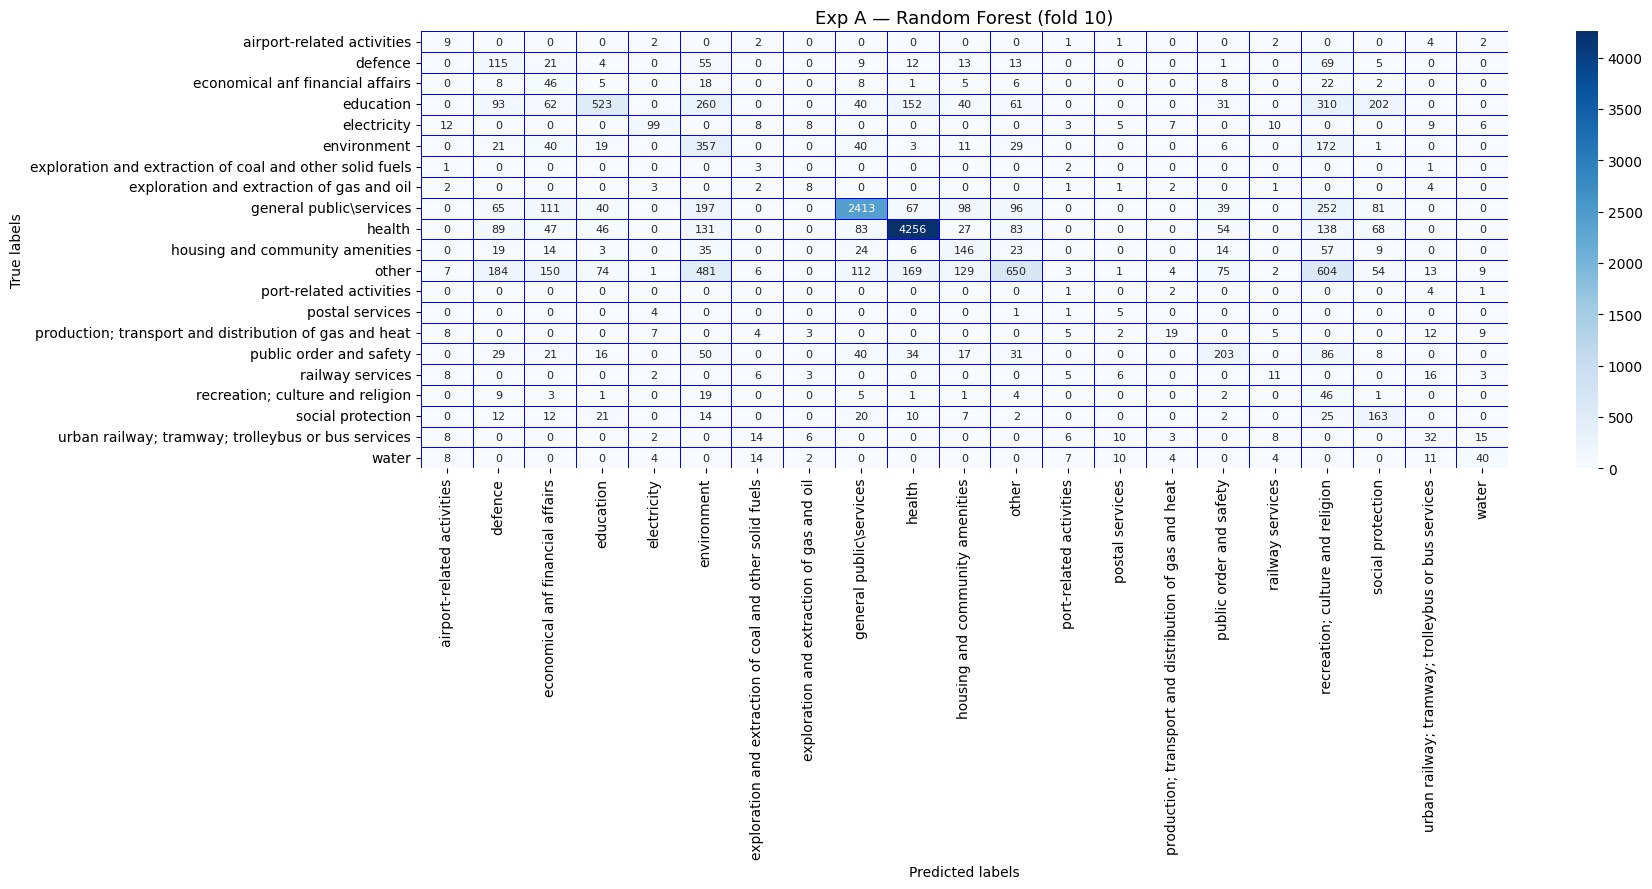

Guardada como Exp_A__Random_Forest_(fold_10).png


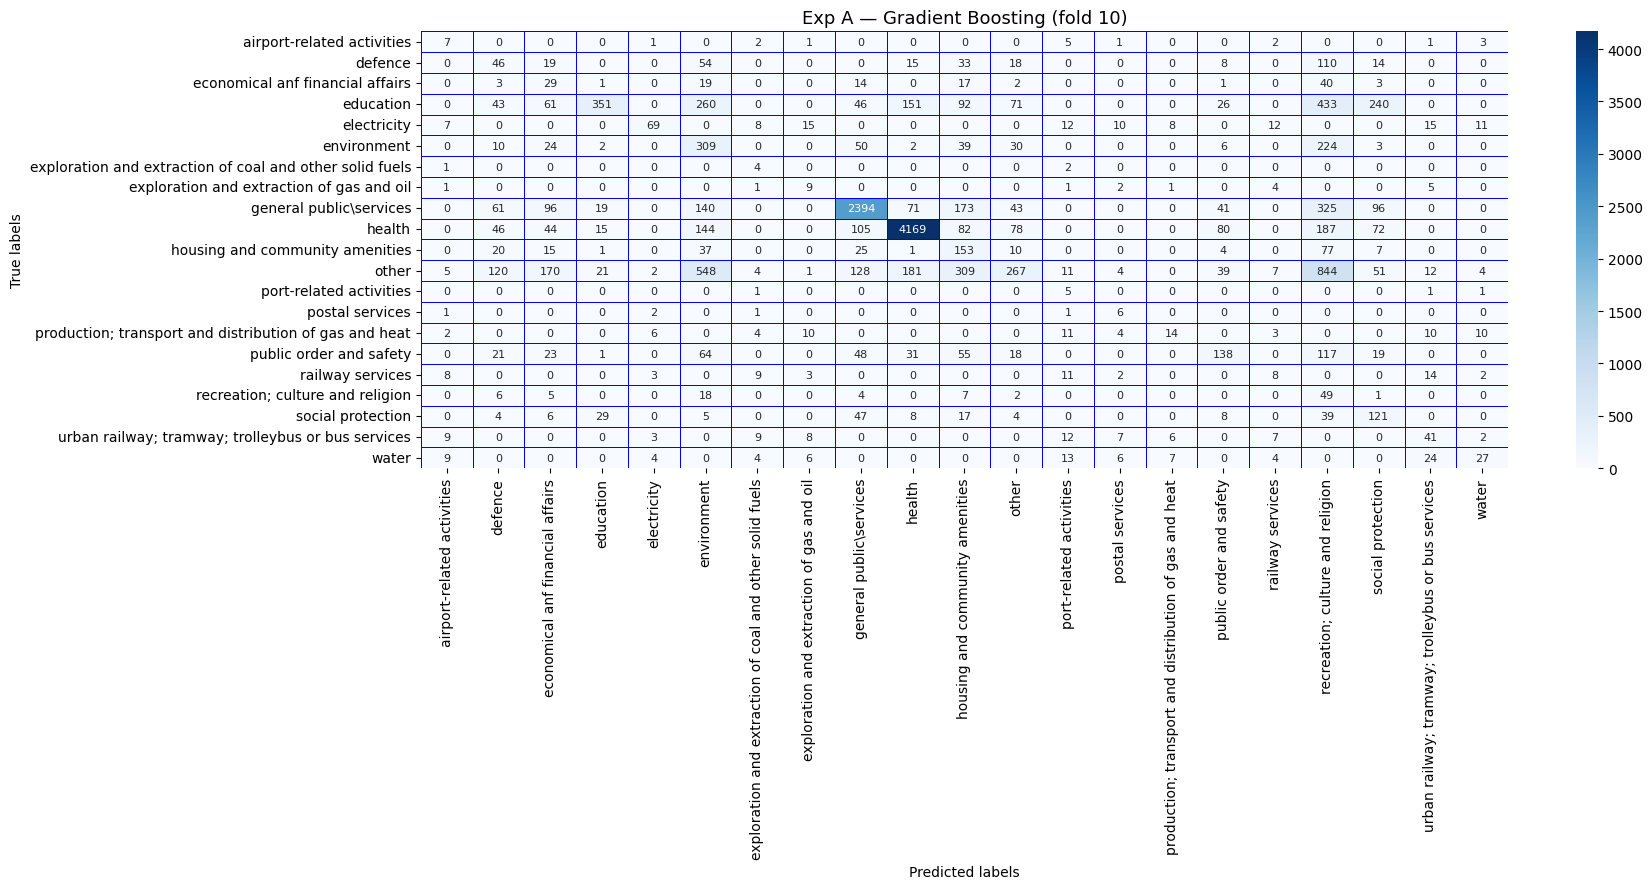

Guardada como Exp_A__Gradient_Boosting_(fold_10).png


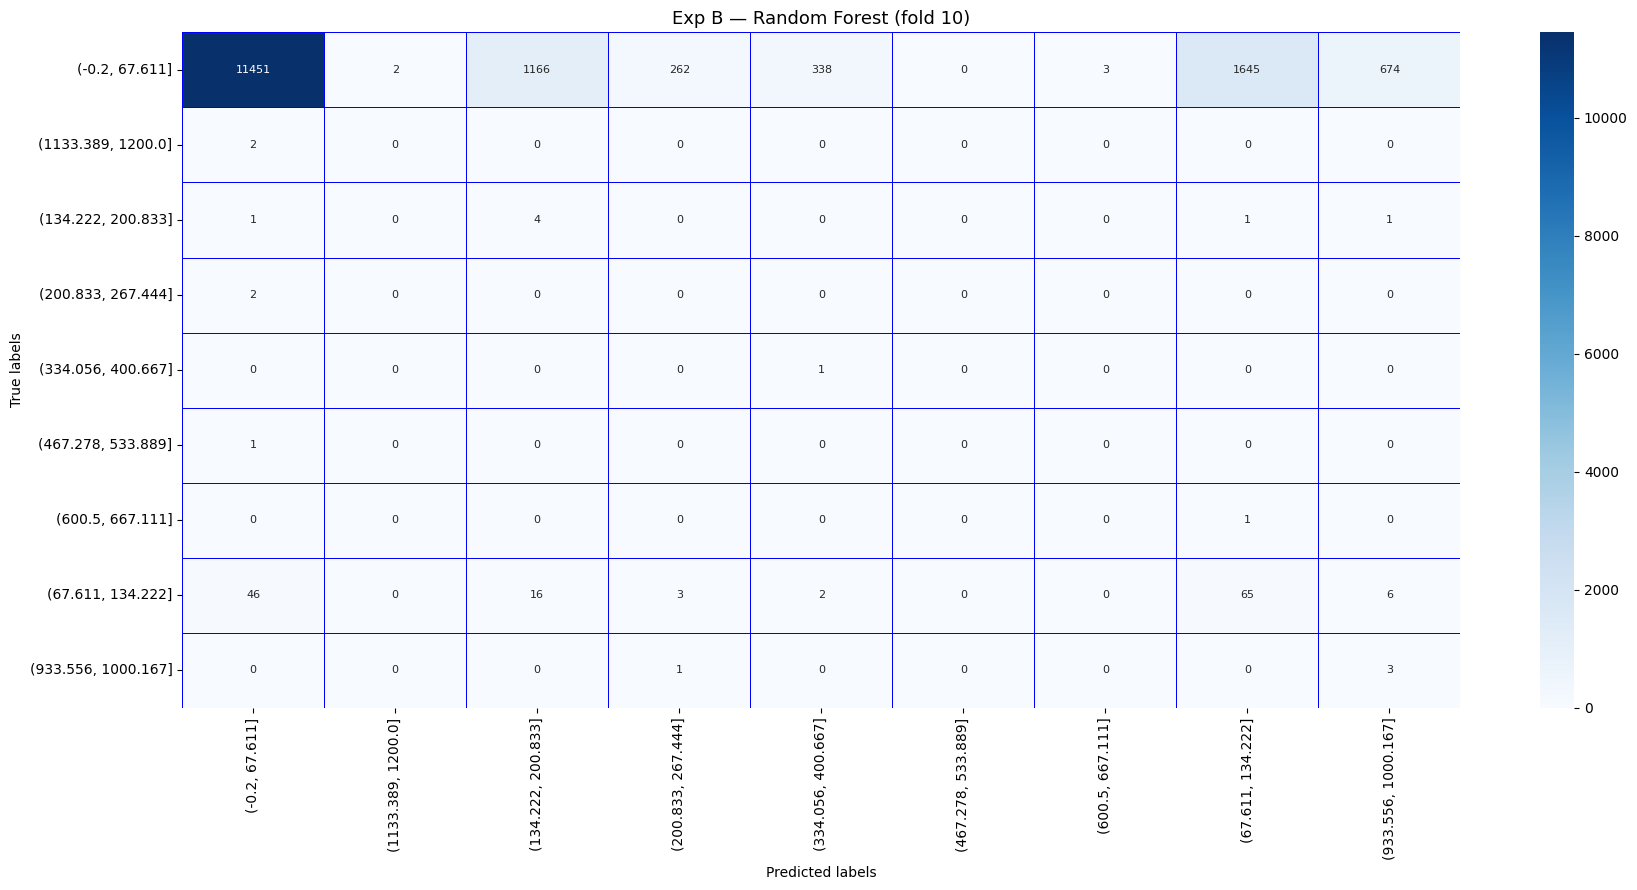

Guardada como Exp_B__Random_Forest_(fold_10).png


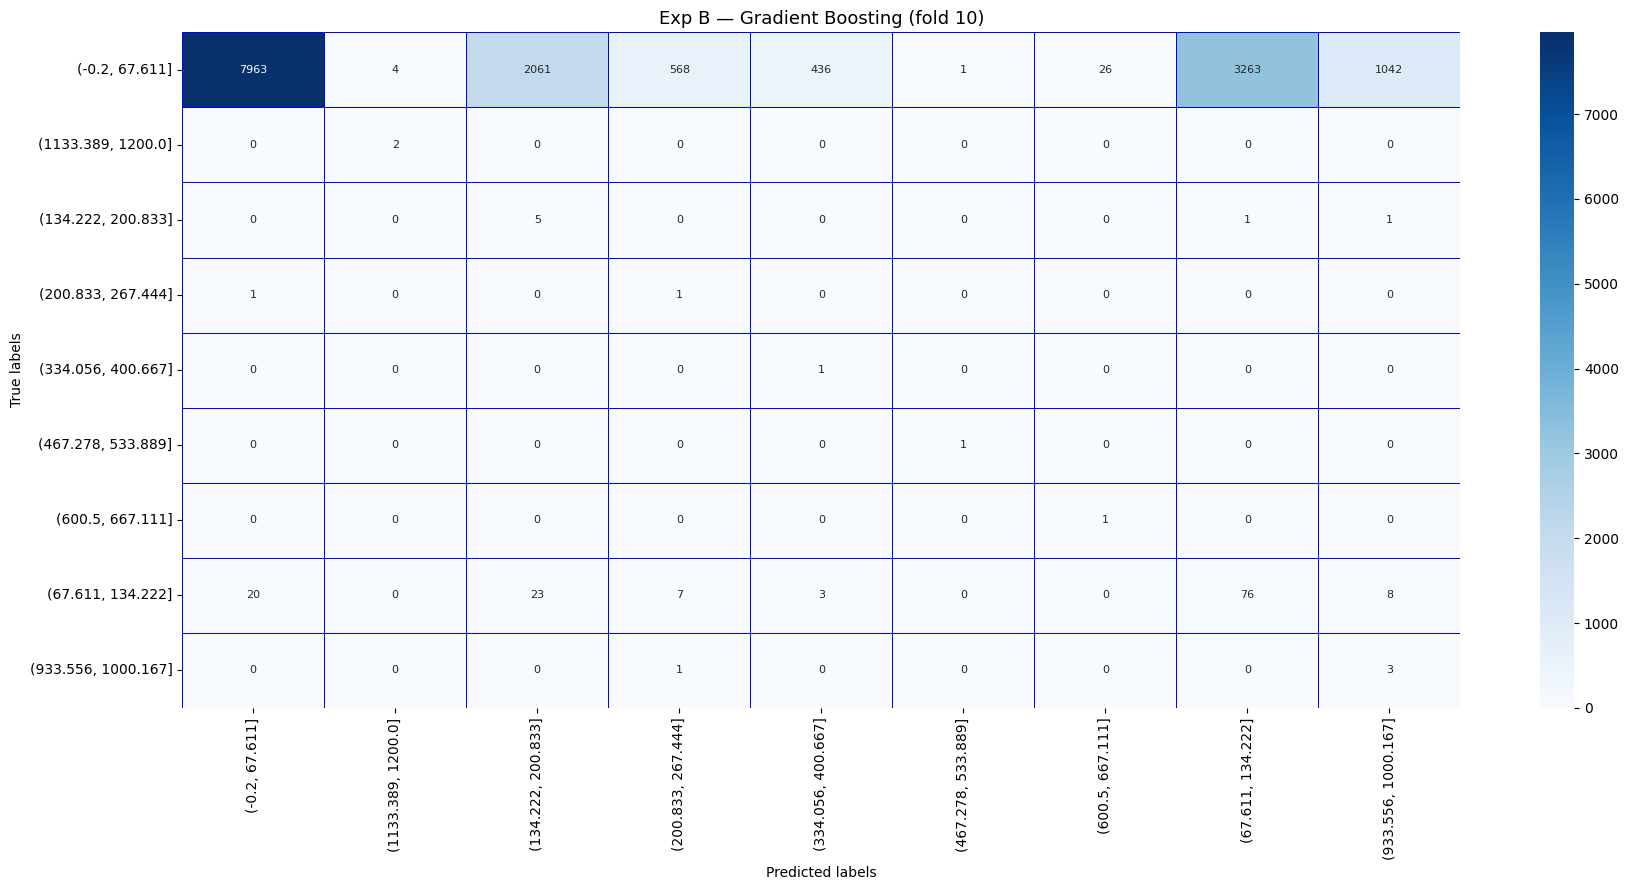

Guardada como Exp_B__Gradient_Boosting_(fold_10).png


In [ ]:
def graficar_matriz(y_test, y_pred, titulo):
    clases = np.unique(y_test)
    cm     = confusion_matrix(y_test, y_pred, labels=clases)
    plt.figure(figsize=(18, 9))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=clases, yticklabels=clases,
                linewidths=0.5, linecolor='blue', annot_kws={'size': 8})
    plt.title(titulo, fontsize=13)
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.tight_layout()
    plt.savefig(titulo.replace(' ','_').replace('—','') + '.png', dpi=150)
    plt.show()
    print(f'Saved as {titulo.replace(" ","_").replace("—","")}.png')

graficar_matriz(res_rf_A['y_test'], res_rf_A['y_pred'], 'Exp A — Random Forest (fold 10)')
graficar_matriz(res_gb_A['y_test'], res_gb_A['y_pred'], 'Exp A — Gradient Boosting (fold 10)')
graficar_matriz(res_rf_B['y_test'], res_rf_B['y_pred'], 'Exp B — Random Forest (fold 10)')
graficar_matriz(res_gb_B['y_test'], res_gb_B['y_pred'], 'Exp B — Gradient Boosting (fold 10)')

## Step 10 — Feature importance

In [ ]:
def tabla_importancia(modelo, nombre, experimento):
    imp = pd.DataFrame({
        'Feature':    used_features,
        'Importance': modelo.feature_importances_
    }).sort_values('Importance', ascending=False)
    print(f'\nFeature importance — {nombre} Exp {experimento}')
    print(imp.to_string(index=False))

tabla_importancia(res_rf_A['modelo'], 'Random Forest',    'A')
tabla_importancia(res_gb_A['modelo'], 'Gradient Boosting','A')
tabla_importancia(res_rf_B['modelo'], 'Random Forest',    'B')
tabla_importancia(res_gb_B['modelo'], 'Gradient Boosting','B')


Importancia de predictores — Random Forest Exp A
            Feature  Importancia
      NUMBER_AWARDS     0.222538
        LOTS_NUMBER     0.217488
      NUMBER_OFFERS     0.138087
 NUMBER_TENDERS_SME     0.116452
         CAE_TYPE_4     0.112458
       GROUP_CPV_33     0.053733
         CAE_TYPE_3     0.040693
       GROUP_CPV_15     0.021231
ISO_COUNTRY_CODE_si     0.019744
      B_ON_BEHALF_n     0.016104
 TYPE_OF_CONTRACT_w     0.013581
   B_MULTIPLE_CAE_n     0.012732
       GROUP_CPV_45     0.012395
         CAE_TYPE_5     0.002284
ISO_COUNTRY_CODE_lu     0.000478

Importancia de predictores — Gradient Boosting Exp A
            Feature  Importancia
         CAE_TYPE_4     0.295543
        LOTS_NUMBER     0.144434
      NUMBER_AWARDS     0.127767
       GROUP_CPV_33     0.105176
         CAE_TYPE_3     0.087036
       GROUP_CPV_15     0.044534
      NUMBER_OFFERS     0.042831
 NUMBER_TENDERS_SME     0.040302
ISO_COUNTRY_CODE_si     0.036367
       GROUP_CPV_45     0.026296
 TYPE

## Step 11 — Save metrics to CSV

Exports all per-fold metrics for reference and reproducibility.

In [ ]:
filas = []
for clave, res in [('RF_A',  res_rf_A), ('GB_A',  res_gb_A),
                   ('RF_B',  res_rf_B), ('GB_B',  res_gb_B)]:
    for fold_i in range(10):
        filas.append({
            'modelo':    clave,
            'fold':      fold_i + 1,
            'accuracy':  res['metricas']['accuracy'][fold_i],
            'precision': res['metricas']['precision'][fold_i],
            'recall':    res['metricas']['recall'][fold_i],
            'f1':        res['metricas']['f1'][fold_i]
        })

df_metricas = pd.DataFrame(filas)
df_metricas.to_csv('metricas_cv_k10.csv', index=False)
print('Metrics saved to metricas_cv_k10.csv')
print(df_metricas.groupby('modelo')[['accuracy','precision','recall','f1']].agg(['mean','std']).round(4))

Métricas guardadas en metricas_cv_k10.csv
       accuracy         precision          recall              f1        
           mean     std      mean     std    mean     std    mean     std
modelo                                                                   
GB_A     0.5180  0.0031    0.3419  0.0118  0.3960  0.0186  0.2960  0.0096
GB_B     0.5126  0.0061    0.1443  0.0275  0.5306  0.0676  0.1383  0.0269
RF_A     0.5728  0.0025    0.3794  0.0122  0.4448  0.0237  0.3550  0.0130
RF_B     0.7260  0.0049    0.1300  0.0317  0.4131  0.1103  0.1327  0.0425
